# Cruciform Fixed Source Problem

In [13]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('forkserver')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad
import pandas as pd

from ttnte.xs.benchmarks import Server
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, fixed_source
from ttnte.cad import Patch
from ttnte.cad.curves import qtrlobe
from ttnte.sources import IsotropicInternalSource
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 4096

# Get XS data
xs_server = Server(
    {
        "Source": {
            "total": np.array([0.01]),
            "scatter_gtg": np.array([[[0.008]]]),
        },
        "Void": {
            "total": np.array([0]),
            "scatter_gtg": np.array([[[0]]]),
        },
        "Shield": {
            "total": np.array([3]),
            "scatter_gtg": np.array([[[0.5]]]),
        }
    }
)

In [16]:
## Initialize dimensional variables
X = 10 # Channel pitch

# Cruciform
R = 2 # Radius defining valleys of fixed source
delta = 1 # Width of lobes
d2 = delta * 0.5 # Half width of lobes
x = 0.25 # Portrusion of lobes

# Shielding
I = 3.75 # Inner radius
O = 4.5 # Outer radius

# NURBS curves
origin = cad.line(p0=(0, 0), p1=(0, 0))
cruciform = qtrlobe(outrad = R, portrs = x, hfwidth = d2)
circleI = cad.circle(radius = I, angle = [np.pi/2, 0] )
circleO = cad.circle(radius = O, angle = [np.pi/2, 0] )
topedge = cad.line(p0=(0, X / 2), p1=(X / 2, X / 2))
corner = cad.line(p1=(X / 2, X / 2), p0=(X / 2, X / 2))
rightedge = cad.line(p1=(X / 2, 0), p0=(X / 2, X / 2))

In [23]:
# Create IGA mesh object
mesh = IGAMesh(max_processes=32)

# Create and add NURBS surfaces
sections = [0, 1/3, 2/3, 1]
edges = [topedge, corner, rightedge]

for i in range(len(sections) - 1):
    # Line sections
    csec = origin.slice(0, sections[i], sections[i + 1])
    ssec = cruciform.slice(0, sections[i], sections[i + 1])
    isec = circleI.slice(0, sections[i], sections[i + 1])
    osec = circleO.slice(0, sections[i], sections[i + 1])

    # Create source patch
    source = Patch(cad.ruled(csec, ssec), "Source")
    source.set_source(IsotropicInternalSource(np.ones((1, *source.shape))))
    mesh.add_patch(source)

    # Add remaining
    mesh.add_patch(Patch(cad.ruled(ssec, isec), "Void"))
    mesh.add_patch(Patch(cad.ruled(isec, osec), "Shield"))
    mesh.add_patch(Patch(cad.ruled(osec, edges[i]), "Void"))

In [24]:
# Refine mesh resolution
mesh.refine(factor=7, degree=3)

# Connect patches
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("left", "bottom"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=3, name=None, num_patches=12, reflective_boundaries=True)
  -> Patch(material=Source, source=IsotropicInternalSource, id=33, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Void, source=None, id=34, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Shield, source=None, id=35, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Void, source=None, id=36, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Source, source=IsotropicInternalSource, id=37, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Void, source=None, id=38, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Shield, source=None, id=39, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Void, source=None, id=40, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Source, source=IsotropicInternalSource, id=41, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Void, source=None, id=42, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Shield, source=None, id=43, name=None, shape=(10, 10), backend=geomdl)
  -> Patch(material=Void, source=None, id=44, name=None, shape=(10, 10), backend=geomdl)

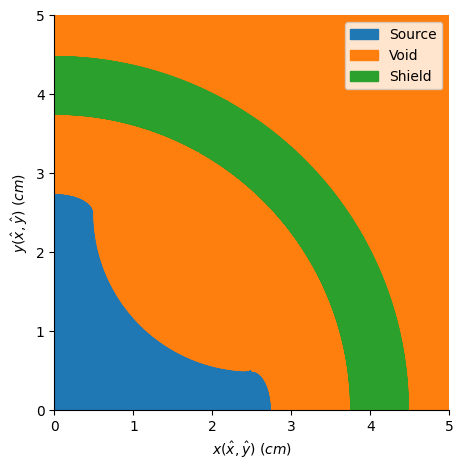

In [25]:
# Plot final mesh
ax = mesh.plot(plot_ctrlpts=False)
plt.tight_layout()
plt.savefig("./figs/cruciform.png", dpi=300)
plt.show()

## Assemble Matrix and TT Operators

In [7]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save COO information
assembler.save_info("./coo_info_ba.csv")

# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    max_processes=2,
)
tts = assembler.build(use_tt=False, eps=1e-10, q=False)

# Save TT information
assembler.save_info("./tt_info_ba.csv")

Running MatrixAssembler.build()
Discretization: N = 4096, G = 1, P = 12, A = 10, B = 10
Operators: H, S, q, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/12 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 107.01 s)
Step            Shape                     Compression
H               4915200,4915200             48703.92
S               4915200,4915200           284573961.55
q               4915200                         1.00
B_out           4915200,4915200           1508815.66
B_in            4915200,4915200           1566490.34
Running TTAssembler.build()
Discretization: N = 4096, G = 1, P = 12, A = 10, B = 10
Operators: H, S, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/12 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 135.88 s)
Step            Ranks                     Compression
H               3,3,3,27,39               173378050.29
S               1,1,1,6,18                1555846924.27
B_out           4,64,170,62,8             1862484.17
B_in            6,66,171,64,8             1777665.93


## Solve

In [8]:
# Run fixed source calculation
psi = fixed_source(
    T=LinearOperator([tts.H, mats.B_out - mats.B_in, -tts.S], N=assembler.N, M=assembler.M),
    q=mats.q,
    device=1,
    max_iters=50,
    tol=1e-10,
    restarts=250,
)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi.unsqueeze(3))

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

GMRES Finished
Elapsed Time: 990.1139786243439


## Plot and Compare to OpenMC

In [9]:
leakage_frac_openmc = [0.06913173400000001, 1.1401809264552177e-05]
phi_mc = np.load("./openmc/data/mesh_flux.npy")
phi_mc_stdev = np.load("./openmc/data/mesh_stdev.npy")

leakage = assembler.outward_current(psi)
production = assembler.total_production()
leakage_frac = float(leakage / production)
print(f"TIDG leakage fraction = {leakage_frac}")
print(f"OpenMC leakage fraction = {leakage_frac_openmc[0]} +/- {leakage_frac_openmc[1]}")
print(f"TIDG is {(leakage_frac - leakage_frac_openmc[0]) / leakage_frac_openmc[1]} stdevs from OpenMC")

TIDG leakage fraction = 0.06915910230498
OpenMC leakage fraction = 0.06913173400000001 +/- 1.1401809264552177e-05
TIDG is 2.4003475540564114 stdevs from OpenMC


<Figure size 640x480 with 0 Axes>

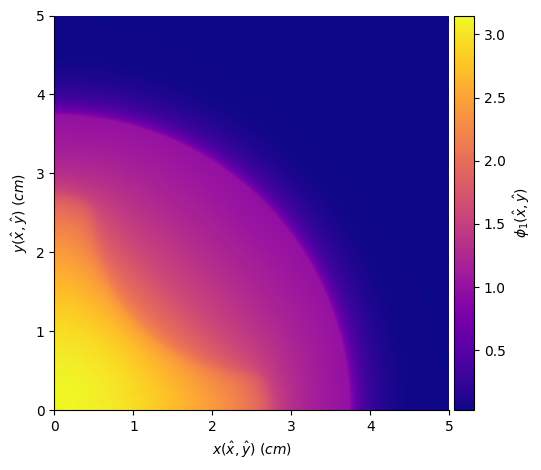

In [10]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}.png", dpi=300)
    plt.show()

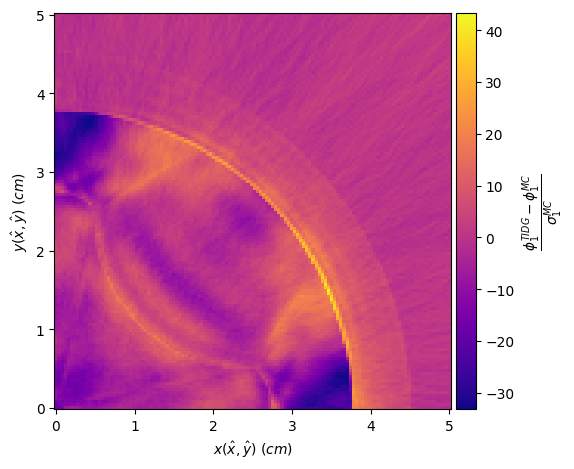

,Group,Minimum,Q1,Median,Q2,Maximum,Mean
0,1,-33.230488,-1.097824,0.78261,4.294495,43.298384,1.021358
1,Total,-33.230488,-1.097824,0.78261,4.294495,43.298384,1.021358


In [14]:
# Regular mesh
X, Y = np.meshgrid(
    np.linspace(0, 5, phi_mc.shape[1]),
    np.linspace(0, 5, phi_mc.shape[2]),
)

# Calculate z-score within each voxel
z = (phi_avg - phi_mc) / phi_mc_stdev
stats = {
    "Group": list(range(1, xs_server.num_groups + 1)) + ["Total"],
    **{
        name: np.zeros(xs_server.num_groups + 1) 
        for name in 
        ["Minimum", "Q1", "Median", "Q2", "Maximum", "Mean"]
    },
}

for g in range(xs_server.num_groups):    
    # Plot z-score
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(X, Y, z[g,], cmap="plasma")
    divider = make_axes_locatable(ax)
    cbar = plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
    )
    cbar.set_label(
        "$\\frac{\\phi^{TIDG}_{" 
        + str(g + 1) 
        + "} - \\phi^{MC}_{"
        + str(g + 1) 
        + "}}{\\sigma^{MC}_{"
        + str(g + 1) 
        + "}}$", 
        size=14
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_error.png", dpi=300)
    plt.show()

    # Get some stats
    stats["Minimum"][g] = np.min(z[g,])
    stats["Q1"][g] = np.percentile(z[g,], 25)
    stats["Median"][g] = np.median(z[g,])
    stats["Q2"][g] = np.percentile(z[g,], 75)
    stats["Maximum"][g] = np.max(z[g,])
    stats["Mean"][g] = np.mean(z[g,])

stats["Minimum"][-1] = np.min(z)
stats["Q1"][-1] = np.percentile(z, 25)
stats["Median"][-1] = np.median(z)
stats["Q2"][-1] = np.percentile(z, 75)
stats["Maximum"][-1] = np.max(z)
stats["Mean"][-1] = np.mean(z)
pd.DataFrame(stats)